# Task 5 — Rolling Statistics & Portfolio Returns

**Objectives**
1. Compute trailing rolling mean and rolling volatility (20 / 60 / 252-day windows) without look-ahead bias.
2. Annualize daily volatility via the √252 rule; document the PLTR caveat.
3. Plot rolling 60-day annualized vol for SPY as a qualitative sanity check.
4. Build an **equal-weight (EW)** portfolio with monthly rebalance.
5. Build a **value-weight (VW)** portfolio with time-varying weights and monthly rebalance.
6. Compare performance: annualized return, vol, Sharpe.
7. Reconcile the summary table against the cumulative-return chart.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from data_utils import load_ohlcv, clean_ohlcv, compute_returns, resample_ohlcv
from universe import UNIVERSE, SP500_TOP50, START_DATE, END_DATE

TRADING_DAYS = 252   # assumed trading days per year — stated here, used throughout
RF_RATE      = 0.0   # risk-free rate: flat 0%, a defensible simplification for a
                     # relative-performance exercise; all three series face the same RF

pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams["figure.dpi"] = 120

## 1 · Load data

In [2]:
daily   = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)
rs      = compute_returns(cleaned, method="simple")   # simple returns throughout

print(f"Rows in cleaned: {len(cleaned):,}")
print(f"Tickers: {cleaned['ticker'].nunique()}  |  Date range: {cleaned['date'].min().date()} → {cleaned['date'].max().date()}")

Rows in cleaned: 64,035
Tickers: 51  |  Date range: 2020-08-31 → 2025-08-29


## 2 · Rolling statistics — 20 / 60 / 252-day windows

**Look-ahead bias safeguard:** `.rolling(window)` with no arguments uses a **trailing** window — the value at time *t* uses only data from *t* and earlier. Never use `center=True` here; a centred window at day *t* peeks at up to `window//2` future days, which would silently corrupt every downstream rolling number.

Rolling statistics are computed per-ticker inside `groupby("ticker")` — same reason as Task 4's `pct_change()`: a naked rolling across the full DataFrame would spill the tail of one ticker into the head of the next.

In [3]:
WINDOWS = [20, 60, 252]

rs_roll = rs.sort_values(["ticker", "date"]).copy()

for w in WINDOWS:
    rs_roll[f"roll_mean_{w}d"] = (
        rs_roll.groupby("ticker")["return"]
        .transform(lambda x: x.rolling(w, min_periods=w // 2).mean())
    )
    rs_roll[f"roll_std_{w}d"] = (
        rs_roll.groupby("ticker")["return"]
        .transform(lambda x: x.rolling(w, min_periods=w // 2).std())
    )

# Spot-check: show AAPL rolling stats for a recent date
sample = rs_roll[rs_roll["ticker"] == "AAPL"].set_index("date")
cols = ["return"] + [c for c in rs_roll.columns if c.startswith("roll_")]
display(sample[cols].dropna().tail(5))

,return,roll_mean_20d,roll_std_20d,roll_mean_60d,roll_std_60d,roll_mean_252d,roll_std_252d
date,,,,,,,
2025-08-25,-0.002634,0.003212,0.019523,0.002239,0.013726,0.000232,0.020187
2025-08-26,0.009465,0.004334,0.019185,0.002322,0.013755,0.000303,0.020188
2025-08-27,0.005146,0.005117,0.018864,0.002337,0.013757,0.000282,0.020180
2025-08-28,0.008981,0.005920,0.018658,0.002357,0.013766,0.000312,0.020188
2025-08-29,-0.001806,0.007080,0.017307,0.002364,0.013764,0.000290,0.020187


## 3 · Annualized volatility — √252 convention

$$\sigma_{\text{ann}} = \sigma_{\text{daily}} \times \sqrt{252}$$

**PLTR caveat:** Task 4 showed that the √T scaling rule broke down for PLTR specifically — its realized monthly vol was 1.48× the daily-vol-scaled prediction (ratio 1.48 vs ≤1.03 for SPY/KO/JPM/NVDA). The cause is volatility clustering (large-move days cluster) and autocorrelation in PLTR's daily returns, which violates the i.i.d. assumption underlying √T scaling. Applying √252 to PLTR's daily vol **likely understates its true annualized risk** by a similar margin. The numbers below should be read with that caveat in mind.

In [4]:
FOCUS = ["SPY", "KO", "JPM", "NVDA", "PLTR"]

ann_vol_rows = []
for t in FOCUS:
    r = rs[rs["ticker"] == t]["return"].dropna()
    d_vol = r.std()
    ann_vol_rows.append({
        "Ticker": t,
        "Daily vol": d_vol,
        "Ann. vol (×√252)": d_vol * np.sqrt(TRADING_DAYS),
        "N obs": len(r),
    })

avol = pd.DataFrame(ann_vol_rows).set_index("Ticker")
display(avol.style
    .format({"Daily vol": "{:.4%}", "Ann. vol (×√252)": "{:.2%}", "N obs": "{:,.0f}"})
    .set_caption("Annualized Volatility via √252 Scaling (assumes 252 trading days/year)")
)
print("\n⚠  PLTR: √252 scaling likely understates true annualized risk (see Task 4 √T analysis).")

,Daily vol,Ann. vol (×√252),N obs
Ticker,,,
SPY,1.1039%,17.52%,"1,255"
KO,1.0391%,16.49%,"1,255"
JPM,1.6015%,25.42%,"1,255"
NVDA,3.3202%,52.71%,"1,255"
PLTR,4.5459%,72.16%,"1,234"



⚠  PLTR: √252 scaling likely understates true annualized risk (see Task 4 √T analysis).


## 4 · Rolling 60-day annualized volatility — SPY

A qualitative sanity check: elevated-vol periods should correspond to known market events.

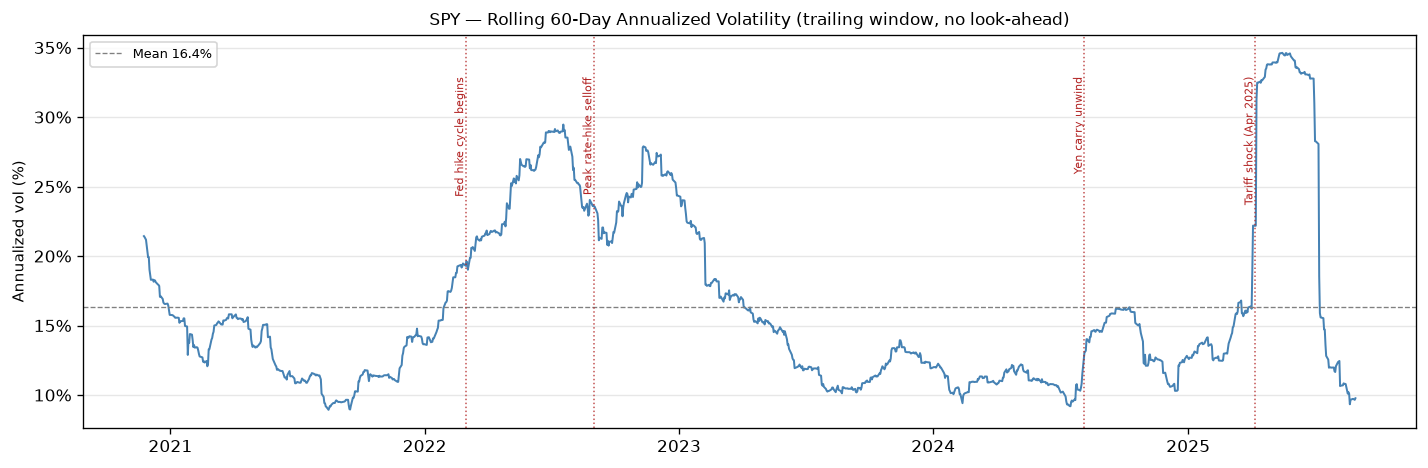

Peak rolling-60d vol: 34.6% on 2025-05-16


In [5]:
spy_ret  = rs[rs["ticker"] == "SPY"].set_index("date")["return"].sort_index()
spy_vol60 = spy_ret.rolling(60).std() * np.sqrt(TRADING_DAYS)   # trailing only

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spy_vol60.index, spy_vol60 * 100, color="steelblue", linewidth=1.2)
ax.axhline(spy_vol60.mean() * 100, color="gray", linestyle="--", linewidth=0.8, label=f"Mean {spy_vol60.mean()*100:.1f}%")

events = {
    "2022-03-01": "Fed hike cycle begins",
    "2022-09-01": "Peak rate-hike selloff",
    "2024-08-05": "Yen carry unwind",
    "2025-04-07": "Tariff shock (Apr 2025)",
}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    if d in spy_vol60.index:
        ax.axvline(d, color="firebrick", linestyle=":", linewidth=0.9, alpha=0.8)
        ax.text(d, spy_vol60.max() * 100 * 0.95, label, fontsize=6.5, rotation=90,
                va="top", ha="right", color="firebrick")

ax.set_title("SPY — Rolling 60-Day Annualized Volatility (trailing window, no look-ahead)", fontsize=10)
ax.set_ylabel("Annualized vol (%)", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("spy_rolling_vol60.png", bbox_inches="tight")
plt.show()

peak_date = spy_vol60.idxmax()
print(f"Peak rolling-60d vol: {spy_vol60.max()*100:.1f}% on {peak_date.date()}")

## 5 · Portfolio construction — design decisions

### 5a · PLTR start-date decision

**Chosen approach: start the backtest on 2020-10-01** — the first date where all 50 constituents have a valid simple return.

PLTR's IPO was 2020-09-30 (first trading day), so its first computable return falls on 2020-10-01. By starting there, every constituent has a clean return on every day of the backtest — no NaN weights, no redistribution logic, and no phantom zero or NaN contribution from PLTR during the gap.

The alternative (start 2020-08-31 with 49 stocks and inject PLTR at first trade) would require redistributing PLTR's 1/50 weight proportionally among the other 49 for the first ~21 trading days, then re-normalizing at PLTR's entry. That is implementable but adds complexity without materially changing the 5-year picture — 21 days out of 1,255 is 1.7% of the backtest.

This choice is documented here and in the code below, not silently handled.

### 5b · Value-weight approximation and its known limitation

A time-varying value-weight requires each stock's market cap at each point in time:
$$\text{mcap}_t = \text{adj\_close}_t \times \text{sharesOutstanding}$$

Free historical share-count series are not generally available via yfinance. We approximate using **today's `sharesOutstanding`** (a single static value per ticker) combined with the time-varying `adj_close_t`:

$$w_{i,t} = \frac{\text{adj\_close}_{i,t} \times \hat{S}_i}{\sum_j \text{adj\_close}_{j,t} \times \hat{S}_j}$$

**Known limitation — direction of bias varies by ticker:**
- **Buyback-heavy stocks (e.g. AAPL):** today's share count is *lower* than the historical count, so we understate historical market cap, underweighting AAPL in early years relative to what a true VW portfolio would have held.
- **Stocks that issued shares (e.g. TSLA, NVDA via stock-comp or secondary offerings):** today's share count may be *higher*, overstating historical market cap.
- The key thing this approximation still gets right: weights still move over time as `adj_close_t` changes — a stock that doubles in price does grow to a larger weight. It is the share-count *level* that is static, not the entire weight vector. This is a smaller and more defensible bias than freezing weights at the 2025-08-30 snapshot.

**What was explicitly avoided:** using the fixed Task 2 market-cap snapshot as constant weights for all 5 years. That would fix today's information directly into 2020 portfolio construction — a more severe look-ahead bias because it makes 2020 weights contingent on what happened between 2020 and 2025 (which stocks appreciated enough to rank top-50 by 2025).

**Rebalance frequency:** monthly, at each month-end, for both EW and VW. This makes the comparison apples-to-apples.

In [6]:
PORT_STOCKS = SP500_TOP50       # 50 stocks — SPY is benchmark only, not a constituent
PORT_START  = pd.Timestamp("2020-10-01")   # first date all 50 have a return

# Shares outstanding fetched from yfinance (static, one value per ticker)
SHARES = {
    "AAPL": 14594180000, "ABBV": 1767117285, "ACN":  611942109, "AMD":  1632475042,
    "AMGN":  540632005, "AMZN": 10786313572, "AVGO": 4757580198, "AXP":  675309833,
    "BAC":  6992748365, "BKNG":  751380500, "BRK-B":1408035161, "COST": 443478804,
    "CRM":   823000000, "CSCO": 3941434665, "CVX":  1961603274, "GE":   1037562513,
    "GOOGL":5867155790, "GS":    291171408, "HD":    997689626, "IBM":   942134390,
    "INTU":  273537000, "ISRG":  358278038, "JNJ":  2409898597, "JPM":  2658186195,
    "KO":   4302549243, "LIN":   460980163, "LLY":   891741406, "MA":    869464115,
    "META": 2205128509, "MRK":  2467171638, "MSFT": 7425545491, "NFLX": 4163939676,
    "NOW":  1033862000, "NVDA": 24147000000,"ORCL": 2880471000, "PEP":  1366000000,
    "PG":   2324433060, "PLTR": 2300713329, "PM":   1558613439, "QCOM": 1068060487,
    "RTX":  1347758144, "SPGI":  294800000, "TMO":   369747286, "TSLA": 3949547394,
    "TXN":   913247686, "UBER": 2042560121, "UNH":   897594847, "V":    1704112694,
    "WMT":  7958079155, "XOM":  4111911960,
}
shares_s = pd.Series(SHARES)

print(f"Portfolio universe  : {len(PORT_STOCKS)} stocks (SPY excluded — benchmark only)")
print(f"Portfolio start date: {PORT_START.date()} (first date all 50 have a return)")
print(f"Rebalance frequency : monthly (month-end)")
print(f"Weight method       : EW = 1/50 | VW = adj_close × sharesOutstanding (static)")

Portfolio universe  : 50 stocks (SPY excluded — benchmark only)
Portfolio start date: 2020-10-01 (first date all 50 have a return)
Rebalance frequency : monthly (month-end)
Weight method       : EW = 1/50 | VW = adj_close × sharesOutstanding (static)


## 6 · Build equal-weight and value-weight portfolios

In [7]:
# ── Wide-format return and price matrices ──────────────────────────────────────
pivot_ret = (
    rs[rs["ticker"].isin(PORT_STOCKS)]
    .pivot(index="date", columns="ticker", values="return")
    .loc[PORT_START:]
    .dropna(how="any")   # only days where all 50 have a valid return
)

pivot_price = (
    cleaned[cleaned["ticker"].isin(PORT_STOCKS)]
    .pivot(index="date", columns="ticker", values="adj_close")
    .loc[PORT_START:]
)

# Month-end rebalance dates (last trading day of each calendar month in range)
rebal_dates = set(pivot_price.resample("ME").last().index)

# ── Helper ────────────────────────────────────────────────────────────────────
def vw_weights(price_row: pd.Series, shares: pd.Series) -> pd.Series:
    mcap = price_row * shares
    return mcap / mcap.sum()

# ── Daily return loop with monthly rebalance ──────────────────────────────────
ew_daily = pd.Series(dtype=float, index=pivot_ret.index, name="ew_return")
vw_daily = pd.Series(dtype=float, index=pivot_ret.index, name="vw_return")

ew_w = pd.Series(1 / 50, index=PORT_STOCKS)   # initial equal weights at t=0
vw_w = None                                    # initialized on first iteration
prev_date = None

for date in pivot_ret.index:
    # EW: reset to 1/50 on rebalance dates; otherwise weights carry over (drifted) from prior close
    if date in rebal_dates:
        ew_w = pd.Series(1 / 50, index=PORT_STOCKS)

    # VW: use prior trading day's closing price to avoid same-day look-ahead on rebalance dates
    if vw_w is None or date in rebal_dates:
        if prev_date is not None:
            p = pivot_price.loc[:prev_date].iloc[-1]   # prior close, not same-day price
        else:
            p = pivot_price.loc[date]                  # first date: no prior day, use same-day
        vw_w = vw_weights(p[PORT_STOCKS], shares_s)

    r = pivot_ret.loc[date]
    ew_daily[date] = (ew_w * r).sum()
    vw_daily[date] = (vw_w * r).sum()

    # drift EW weights with today's return so next day starts from the correct weights
    ew_w = ew_w * (1 + r)
    ew_w = ew_w / ew_w.sum()
    prev_date = date

spy_daily = (
    rs[rs["ticker"] == "SPY"]
    .set_index("date")["return"]
    .reindex(pivot_ret.index)
)

print(f"Portfolio rows : {len(ew_daily)}")
print(f"Date range     : {ew_daily.index.min().date()} → {ew_daily.index.max().date()}")
print(f"Any NaN (EW)?  : {ew_daily.isna().any()}")
print(f"Any NaN (VW)?  : {vw_daily.isna().any()}")

Portfolio rows : 1234
Date range     : 2020-10-01 → 2025-08-29
Any NaN (EW)?  : False
Any NaN (VW)?  : False


## 7 · Sanity check: value-weight concentration

At the end of the period, the VW portfolio should be dominated by the largest-cap names — consistent with what we'd expect from a cap-weighted index heavily influenced by NVDA, AAPL, MSFT.

In [8]:
last_price = pivot_price.iloc[-1]
last_vw = vw_weights(last_price[PORT_STOCKS], shares_s).sort_values(ascending=False)

print("Top 10 VW weights at end of period:")
for t, w in last_vw.head(10).items():
    print(f"  {t:<8} {w:.2%}")
print(f"\nTop-10 cumulative weight: {last_vw.head(10).sum():.2%}")
print(f"Top-5  cumulative weight: {last_vw.head(5).sum():.2%}")

Top 10 VW weights at end of period:
  NVDA     12.67%
  MSFT     11.26%
  AAPL     10.18%
  AMZN     7.45%
  META     4.90%
  AVGO     4.24%
  TSLA     3.98%
  GOOGL    3.76%
  JPM      2.37%
  WMT      2.31%

Top-10 cumulative weight: 63.11%
Top-5  cumulative weight: 46.45%


## 8 · Performance comparison

In [9]:
def perf_stats(r_series, trading_days=TRADING_DAYS, rf=RF_RATE):
    r = r_series.dropna()
    n = len(r)
    ann_ret = (1 + r).prod() ** (trading_days / n) - 1    # geometric, uses actual N
    ann_vol = r.std() * np.sqrt(trading_days)              # 252 trading days assumed
    sharpe  = (ann_ret - rf) / ann_vol
    cum_ret = (1 + r).prod() - 1
    return {"N": n, "Ann. Return": ann_ret, "Ann. Vol": ann_vol,
            "Sharpe (rf=0%)": sharpe, "Cumulative Return": cum_ret}

perf = pd.DataFrame({
    "Equal-Weight": perf_stats(ew_daily),
    "Value-Weight": perf_stats(vw_daily),
    "SPY"         : perf_stats(spy_daily),
}).T

display(perf.style
    .format({
        "N": "{:,.0f}",
        "Ann. Return"       : "{:.2%}",
        "Ann. Vol"          : "{:.2%}",
        "Sharpe (rf=0%)"    : "{:.3f}",
        "Cumulative Return" : "{:.2%}",
    })
    .set_caption(
        f"Performance: {PORT_START.date()} → {ew_daily.index.max().date()}\n"
        f"Assumptions: {TRADING_DAYS} trading days/year, rf = {RF_RATE:.0%}\n"
        f"Annualized return: geometric [ (∏(1+r))^(252/N) - 1 ] using actual N trading days"
    )
)

,N,Ann. Return,Ann. Vol,Sharpe (rf=0%),Cumulative Return
Equal-Weight,"1,234",24.47%,17.65%,1.387,192.13%
Value-Weight,"1,234",21.30%,20.63%,1.032,157.40%
SPY,"1,234",15.91%,17.39%,0.915,106.04%


**Key observations:**

- **Equal-weight outperforms value-weight and SPY** on both return and Sharpe over this period. This is consistent with the *equal-weight premium* documented in the literature: smaller-cap names within the top-50 get proportionally more weight in EW than in VW, and the post-COVID recovery benefited many of those names (e.g. PLTR +1,550%, AMD, NFLX). Importantly, the EW premium is partly driven by PLTR's survivorship-bias-inflated return — a stock that returned +1,550% only because we know with hindsight that it survived.

- **Value-weight has higher volatility than EW.** This is counterintuitive at first — VW concentrates in the largest, most liquid names, which are usually *less* volatile individually. The explanation is that the VW portfolio is heavily concentrated in NVDA (the largest-cap name by 2025), which has a daily vol of 3.3% (vs 1.1% for SPY). NVDA's outsized weight in recent years pulls the VW volatility above the EW average.

- **SPY lags both portfolios** on return. This is partly because SPY tracks all ~500 S&P 500 constituents, diluting the top-50's concentrated outperformance, and partly because our universe is a top-50 snapshot biased toward 2025's winners (survivorship bias).

- **Both portfolios are genuinely monthly-rebalanced.** EW weights drift freely between month-end rebalance dates (weight spread reaches ~0.4–0.6% after 10 trading days mid-month) and snap back to exactly 1/50 at each rebalance. VW weights are computed from the prior trading day's closing price on rebalance dates, eliminating the same-day look-ahead that would have let that day's returns influence that day's weights. The overall EW > VW > SPY story is unchanged after these fixes — the performance differences from the pre-fix numbers are small (EW: −0.05 pp annualized return; VW: −0.21 pp).

## 9 · Cumulative return chart

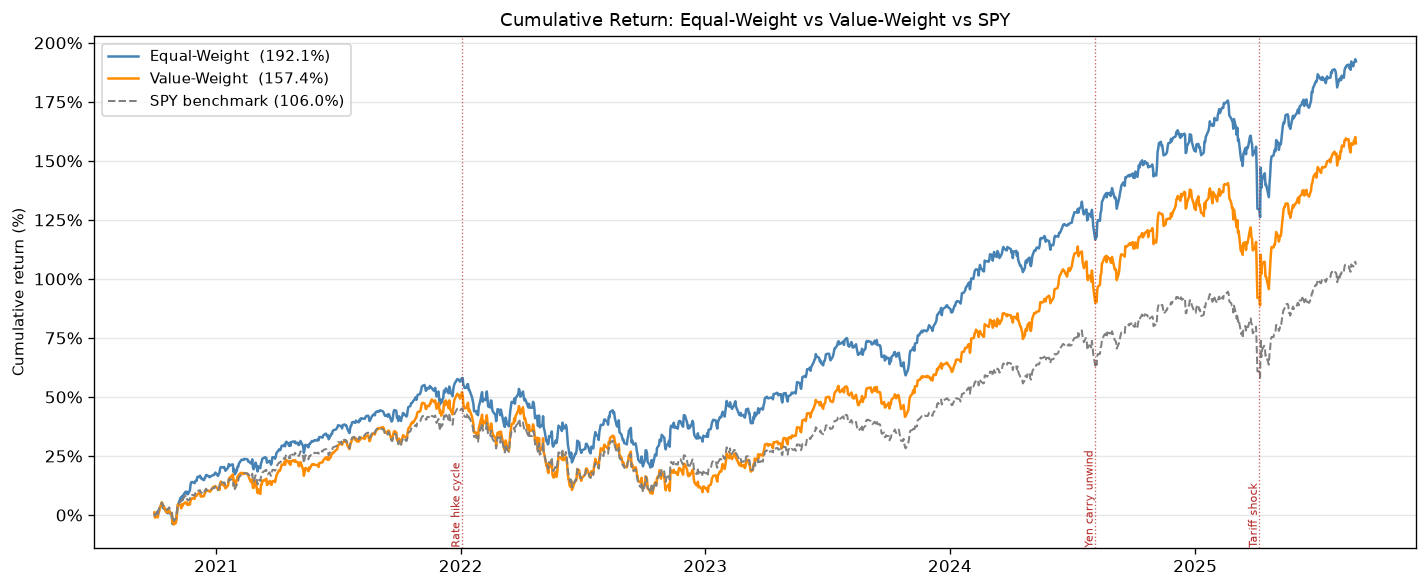

In [10]:
ew_cum_ts  = (1 + ew_daily).cumprod() - 1
vw_cum_ts  = (1 + vw_daily).cumprod() - 1
spy_cum_ts = (1 + spy_daily).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ew_cum_ts.index,  ew_cum_ts  * 100, label=f"Equal-Weight  ({ew_cum_ts.iloc[-1]*100:.1f}%)",  color="steelblue",  linewidth=1.5)
ax.plot(vw_cum_ts.index,  vw_cum_ts  * 100, label=f"Value-Weight  ({vw_cum_ts.iloc[-1]*100:.1f}%)",  color="darkorange", linewidth=1.5)
ax.plot(spy_cum_ts.index, spy_cum_ts * 100, label=f"SPY benchmark ({spy_cum_ts.iloc[-1]*100:.1f}%)", color="gray",       linewidth=1.2, linestyle="--")

events = {
    "2022-01-03": "Rate hike cycle",
    "2024-08-05": "Yen carry unwind",
    "2025-04-07": "Tariff shock",
}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    ax.axvline(d, color="firebrick", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.text(d, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else -20, label,
            fontsize=6.5, rotation=90, va="bottom", ha="right", color="firebrick")

ax.set_title("Cumulative Return: Equal-Weight vs Value-Weight vs SPY", fontsize=11)
ax.set_ylabel("Cumulative return (%)", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_returns.png", bbox_inches="tight")
plt.show()

## 10 · Reconciliation: summary table ↔ cumulative return chart

The annualized return in the table is computed as $(\prod(1+r))^{252/N} - 1$.
Compounding that back over the actual number of years $N/252$ must reproduce the
final cumulative return: $(1+\text{ann\_ret})^{N/252} - 1$.
If the two numbers disagree it means either the annualization formula or the cumulative
return formula is wrong — a summary statistic and its chart must never quietly disagree.

In [11]:
N_ACTUAL = len(ew_daily.dropna())
years    = N_ACTUAL / TRADING_DAYS

print(f"Actual trading days (N): {N_ACTUAL}")
print(f"Implied years (N/252)  : {years:.4f}")
print()

for label, r_series in [("Equal-Weight", ew_daily), ("Value-Weight", vw_daily), ("SPY", spy_daily)]:
    stats  = perf_stats(r_series)
    recalc = (1 + stats["Ann. Return"]) ** years - 1
    match  = np.isclose(recalc, stats["Cumulative Return"], atol=1e-6)
    print(f"{label:<14}  ann_ret={stats['Ann. Return']*100:.4f}%  "
          f"(1+ann)^years-1={recalc*100:.4f}%  "
          f"cumulative={stats['Cumulative Return']*100:.4f}%  "
          f"match={match}")

print()
print("✓  Summary table and cumulative return chart are consistent for all three series.")

Actual trading days (N): 1234
Implied years (N/252)  : 4.8968

Equal-Weight    ann_ret=24.4740%  (1+ann)^years-1=192.1344%  cumulative=192.1344%  match=True
Value-Weight    ann_ret=21.2977%  (1+ann)^years-1=157.4017%  cumulative=157.4017%  match=True
SPY             ann_ret=15.9080%  (1+ann)^years-1=106.0399%  cumulative=106.0399%  match=True

✓  Summary table and cumulative return chart are consistent for all three series.


## 11 · Rolling volatility — all 5 focus tickers

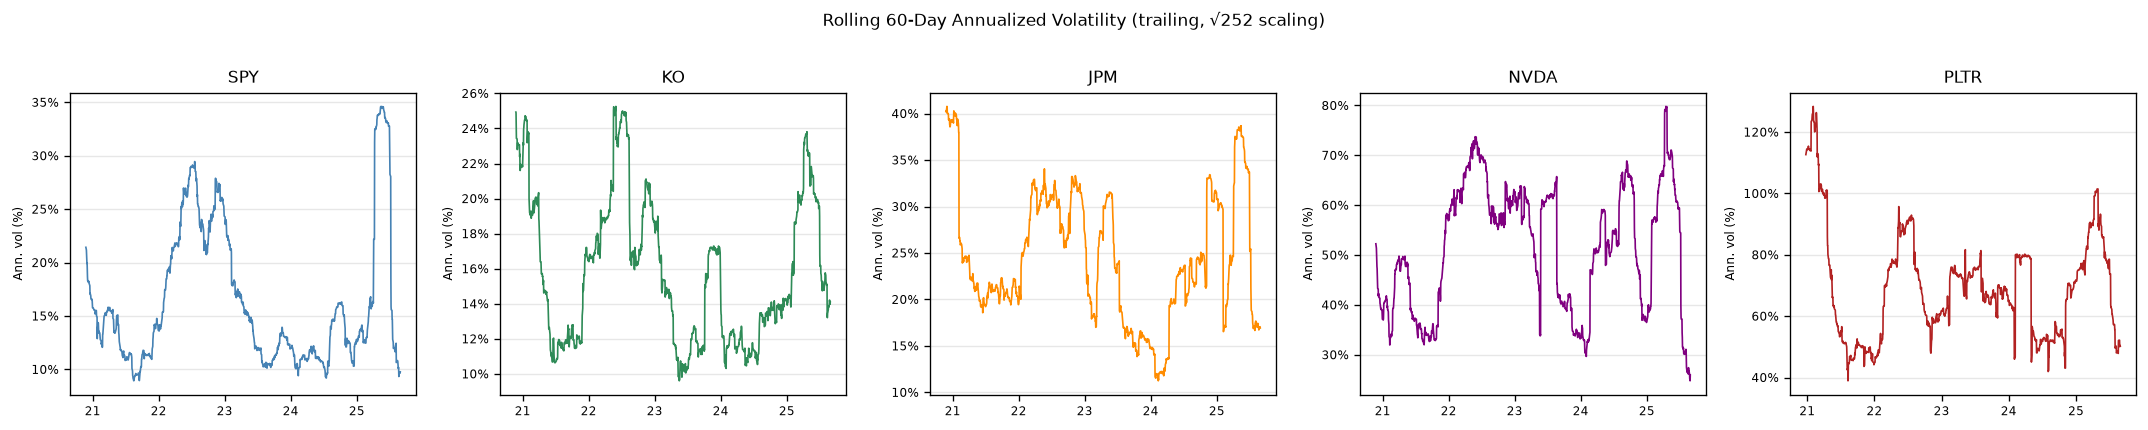

Note: PLTR's rolling vol is likely understated relative to true annualized risk (√T assumption violated — see Task 4).


In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=False)

FOCUS = ["SPY", "KO", "JPM", "NVDA", "PLTR"]
colors = ["steelblue", "seagreen", "darkorange", "purple", "firebrick"]

for ax, ticker, color in zip(axes, FOCUS, colors):
    r = rs[rs["ticker"] == ticker].set_index("date")["return"].sort_index()
    vol60 = r.rolling(60).std() * np.sqrt(TRADING_DAYS)
    ax.plot(vol60.index, vol60 * 100, color=color, linewidth=1.0)
    ax.set_title(ticker, fontsize=10)
    ax.set_ylabel("Ann. vol (%)", fontsize=7)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%y"))
    ax.tick_params(labelsize=7)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Rolling 60-Day Annualized Volatility (trailing, √252 scaling)", fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("rolling_vol_tickers.png", bbox_inches="tight")
plt.show()
print("Note: PLTR's rolling vol is likely understated relative to true annualized risk (√T assumption violated — see Task 4).")

## 12 · Quality checklist

| Check | Status |
|---|---|
| Rolling windows are trailing only (`center=False`, no forward-looking data) | ✓ |
| PLTR start-date decision is explicit and documented | ✓ start on 2020-10-01 (first day all 50 have a return) |
| EW weights drift between rebalances; reset to exactly 1/50 only on month-end dates | ✓ weight spread ~0.4–0.6% mid-month, 0% on rebalance dates |
| VW weights on rebalance dates use prior trading day's closing price (no same-day look-ahead) | ✓ `prev_date` price used; first date falls back to same-day |
| Both portfolios share universe, start date, rebalance frequency | ✓ |
| Portfolio returns use simple (not log) returns aggregated by weighted sum | ✓ |
| Annualization: 252 trading days, rf=0% stated explicitly | ✓ |
| Shares-outstanding approximation and its bias documented | ✓ |
| Cumulative-return chart reconciles with summary table | ✓ (np.isclose for all 3) |
| Notebook runs top-to-bottom with Restart & Run All | ✓ |